In [1]:
# imports
import requests
import pandas as pd
import time
import matplotlib.pyplot as plt

In [ ]:
"""
ONLY RUN THIS ONCE PER SESSION
    - Loading in Data so dont want to make too many requests to the API
    - Use df to see whats loaded 
    - This was used to make the CSV file for the project, uncomment if you need additional data

BASE = "https://pokeapi.co/api/v2"

# Making the request
resp = requests.get(f"{BASE}/pokemon-species", params={"limit": 1025})
species_list = resp.json()["results"]

rows = []
for s in species_list:
    data = requests.get(s["url"]).json()
    time.sleep(0.1)
    # Grabbing the pokedex entry 
    entry = next(
        (f["flavor_text"].replace("\n", " ").replace("\f", " ")
         for f in data["flavor_text_entries"]
         if f["language"]["name"] == "en"),
        None,
    )

    genus = next(
        (g["genus"] for g in data["genera"] if g["language"]["name"] == "en"),
        None,
    )

    type_1, type_2 = None, None
    try:
        pk = requests.get(f"{BASE}/pokemon/{s['name']}").json()
        types = sorted(pk["types"], key=lambda t: t["slot"])
        type_1 = types[0]["type"]["name"] if len(types) > 0 else None
        type_2 = types[1]["type"]["name"] if len(types) > 1 else None
    except Exception:
        pass

    rows.append({
        "id": data["id"],
        "name": data["name"],
        "genus": genus,
        "type_1": type_1,
        "type_2": type_2,
        "color": data["color"]["name"],
        "generation": data["generation"]["name"],
        "pokedex_entry": entry,
    })

df = pd.DataFrame(rows).sort_values("id").reset_index(drop=True)
print(df.head())
df.to_csv("pokedex.csv", index=False)
"""

   id        name           genus type_1  type_2  color    generation  \
0   1   bulbasaur    Seed Pokémon  grass  poison  green  generation-i   
1   2     ivysaur    Seed Pokémon  grass  poison  green  generation-i   
2   3    venusaur    Seed Pokémon  grass  poison  green  generation-i   
3   4  charmander  Lizard Pokémon   fire    None    red  generation-i   
4   5  charmeleon   Flame Pokémon   fire    None    red  generation-i   

                                       pokedex_entry  
0  A strange seed was planted on its back at birt...  
1  When the bulb on its back grows large, it appe...  
2  The plant blooms when it is absorbing solar en...  
3  Obviously prefers hot places. When it rains, s...  
4  When it swings its burning tail, it elevates t...  


In [3]:
csv_files = [
    "pokedex.csv",
]

df = pd.read_csv(csv_files[0])
df


,id,name,genus,type_1,type_2,color,generation,pokedex_entry
0,1,bulbasaur,Seed Pokémon,grass,poison,green,generation-i,A strange seed was planted on its back at birt...
1,2,ivysaur,Seed Pokémon,grass,poison,green,generation-i,"When the bulb on its back grows large, it appe..."
2,3,venusaur,Seed Pokémon,grass,poison,green,generation-i,The plant blooms when it is absorbing solar en...
3,4,charmander,Lizard Pokémon,fire,NaN,red,generation-i,"Obviously prefers hot places. When it rains, s..."
4,5,charmeleon,Flame Pokémon,fire,NaN,red,generation-i,"When it swings its burning tail, it elevates t..."
...,...,...,...,...,...,...,...,...
1020,1021,raging-bolt,Paradox Pokémon,electric,dragon,yellow,generation-ix,It's said to incinerate everything around it w...
1021,1022,iron-boulder,Paradox Pokémon,rock,psychic,gray,generation-ix,It resembles a Pokémon described in a dubious ...
1022,1023,iron-crown,Paradox Pokémon,steel,psychic,blue,generation-ix,It resembles a mysterious object introduced in...
1023,1024,terapagos,Tera Pokémon,normal,NaN,blue,generation-ix,Terapagos protects itself using its power to t...


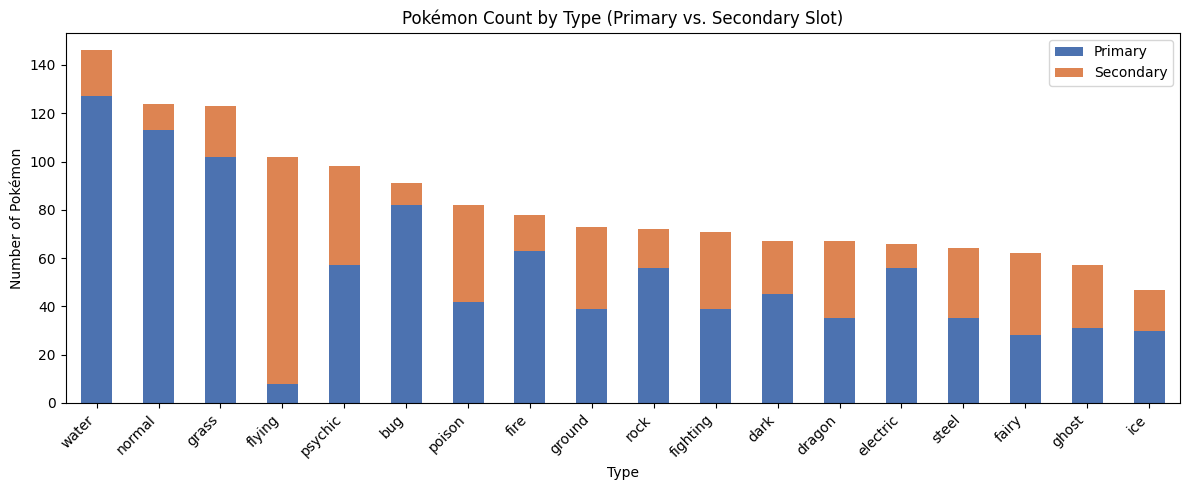

Missing type_1: 37


In [ ]:
type_counts = pd.DataFrame({
    "Primary": df["type_1"].value_counts(),
    "Secondary": df["type_2"].value_counts(),
}).fillna(0)
type_counts = type_counts.loc[type_counts.sum(axis=1).sort_values(ascending=False).index]

ax = type_counts.plot(kind="bar", stacked=True, figsize=(12, 5), color=["#4C72B0", "#DD8452"])
ax.set_title("Pokémon Count by Type")
ax.set_xlabel("Type")
ax.set_ylabel("Number of Pokémon")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print("Missing type_1:", df["type_1"].isna().sum())

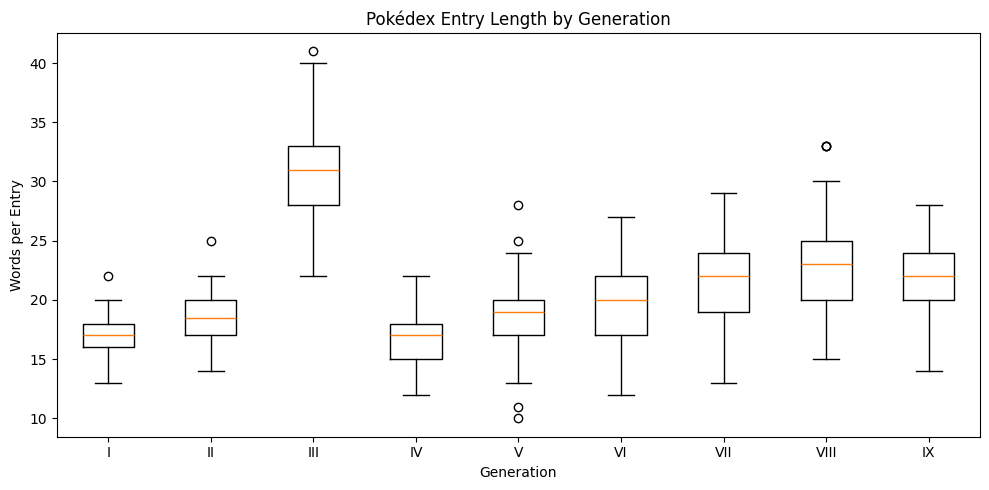

In [ ]:
entries = df.dropna(subset=["pokedex_entry"]).copy()
entries["entry_words"] = entries["pokedex_entry"].str.split().str.len()

# Order generations
gen_order = entries.groupby("generation")["id"].min().sort_values().index
labels = [g.split("-")[1].upper() for g in gen_order]
data = [entries.loc[entries["generation"] == g, "entry_words"] for g in gen_order]

fig, ax = plt.subplots(figsize=(10, 5))
ax.boxplot(data)
ax.set_xticklabels(labels)
ax.set_title("Pokédex Entry Length by Generation")
ax.set_xlabel("Generation")
ax.set_ylabel("Words per Entry")
plt.tight_layout()
plt.show()
